# Model training with Pure Asymmetric Likelihood

#### imports

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
import time

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import zuko

In [20]:
DATASET_PATH = Path("../../datasets/disasters_merged_all_feats.csv")
EVENT_GROUP = 'Flood'
RUN_PATH = Path(f"../../runs/flow_{EVENT_GROUP.lower()}.pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [21]:
torch.manual_seed(42)
np.random.seed(42)

## Data Preparation

In [62]:
df = pd.read_csv(DATASET_PATH)

### Group by event type

In [63]:
df['EVENT_GROUP'].value_counts()

EVENT_GROUP
Wind           152966
Hail            57980
Storm           55795
Flood           49691
Freeze          39347
Drought         20115
Snow            19792
Heat            14279
Heavy Rain      10488
Fog              4943
Wildfire         2505
Lightning        2261
Debris Flow      1047
Avalanche         203
Name: count, dtype: int64

In [64]:
event_group_dfs = {
    'Hail': df[df['EVENT_GROUP'] == 'Hail'].drop(columns=['EVENT_GROUP', 'WIND_SPEED']),
    'Wind': df[df['EVENT_GROUP'] == 'Wind'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Storm': df[df['EVENT_GROUP'] == 'Storm'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Flood': df[df['EVENT_GROUP'] == 'Flood'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Freeze': df[df['EVENT_GROUP'] == 'Freeze'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Drought': df[df['EVENT_GROUP'] == 'Drought'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Snow': df[df['EVENT_GROUP'] == 'Snow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heat': df[df['EVENT_GROUP'] == 'Heat'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heavy Rain': df[df['EVENT_GROUP'] == 'Heavy Rain'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Fog': df[df['EVENT_GROUP'] == 'Fog'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Wildfire': df[df['EVENT_GROUP'] == 'Wildfire'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Lightning': df[df['EVENT_GROUP'] == 'Lightning'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Debris Flow': df[df['EVENT_GROUP'] == 'Debris Flow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Avalanche': df[df['EVENT_GROUP'] == 'Avalanche'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
}

In [65]:
event_group_dfs['Hail'].head()

,DAMAGES,CASUALTIES,DURATION_HOURS,HAIL_SIZE,TIME_DAY_SIN,TIME_DAY_COS,TIME_YEAR_NORM,PRECIPITATION,TMIN,TMAX,...,SLOPE,COV_BARREN,COV_CULTIVATED,COV_VEGETATION,COV_FOREST,COV_WATER,COV_SNOW_ICE,COV_URBAN,RIVER_DISTANCE,SEA_DISTANCE
65,0.0,0,0.0,1.00,0.154204,0.988039,0.0,1404.65,11.66,22.69,...,1.89,0.000,0.716,0.146,0.136,0.002,0.0,0.000,256.4,415.3
72,0.0,0,0.0,0.88,0.353445,0.935455,0.0,1519.92,12.85,24.73,...,6.01,0.003,0.120,0.047,0.769,0.040,0.0,0.021,1082.0,170.3
74,0.0,0,0.0,1.00,0.353445,0.935455,0.0,1478.56,12.41,24.58,...,5.17,0.000,0.328,0.094,0.538,0.001,0.0,0.040,515.2,217.7
76,100.0,0,0.0,1.75,0.353445,0.935455,0.0,1589.20,12.37,24.92,...,7.35,0.000,0.049,0.020,0.930,0.001,0.0,0.000,925.4,142.4
82,0.0,0,0.0,1.00,0.353445,0.935455,0.0,1437.68,12.31,24.38,...,4.94,0.000,0.183,0.119,0.467,0.018,0.0,0.212,377.5,223.6


In [66]:
df = event_group_dfs[EVENT_GROUP]

### Data normalization

In [67]:
TARGET_COLS = ["DAMAGES"]

X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED', # change with hail size for hail
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE'
]

In [68]:
X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

In [69]:
# targets log transformation
Y = np.log1p(Y)

In [70]:
# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

In [71]:
# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)


### Dataset split

In [72]:
# conversion to tensors and move to device
X_train = torch.tensor(X_train).to(device)
Y_train = torch.tensor(Y_train).to(device)

X_val = torch.tensor(X_val).to(device)
Y_val = torch.tensor(Y_val).to(device)

X_test = torch.tensor(X_test).to(device)
Y_test = torch.tensor(Y_test).to(device)


In [73]:
# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)

## Training - Pure Asymmetric Likelihood

In [74]:
EPOCHS = 20
BATCH_SIZE = 512
BASE_LR = 5e-3

# find warmup steps as function of epochs and dataset size
WARMUP_STEPS = int(0.1 * (len(train_ds) // BATCH_SIZE) * EPOCHS)

X_DIM = X_train.shape[1]
Y_DIM = Y_train.shape[1]


In [75]:
class TrainingHistory:
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.lrs = []

In [76]:
def compute_avg_true_pred_diff(flow, test_loader, y_scaler):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze()
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    y_pred = np.expm1(np.clip(y_pred, -20, None))
    y_true = np.expm1(np.clip(y_true, -20, None))
    avg_diff_damages = np.mean(np.abs(y_true[:, 0] - y_pred[:, 0]))
    return avg_diff_damages

In [ ]:
thresholds = [np.log1p(x) for x in [1e2, 1e3, 1e4, 1e5, 1e6, 1e7]]
lams = [2,3,4,5]
res_df = pd.DataFrame(columns=["Threshold", "Lambda", "Val NLL", "Avg True-Pred Diff"])

for threshold in thresholds:
    for lam in lams:
        flow = zuko.flows.NSF(
            features=Y_DIM,
            context=X_DIM,
            transforms=12,
            hidden_features=[128, 128],
            bins=8
        )
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
        test_loader   = DataLoader(test_ds, batch_size=BATCH_SIZE)
        flow = flow.to(device)
        optimizer = torch.optim.Adam(flow.parameters(), lr=BASE_LR, weight_decay=1e-5)
        warmup = torch.optim.lr_scheduler.LinearLR(
            optimizer,
            start_factor=0.1,
            total_iters=WARMUP_STEPS
        )
        cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=EPOCHS * len(train_loader) - WARMUP_STEPS,
            eta_min=1e-5
        )
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer,
            schedulers=[warmup, cosine],
            milestones=[WARMUP_STEPS]
        )
        scaler = torch.amp.GradScaler(device=device)
        ema = torch.optim.swa_utils.AveragedModel(
            flow,
            avg_fn=lambda averaged, model, num_averaged: 0.999 * averaged + 0.001 * model
        )
        history = TrainingHistory()
        best_val_loss = np.inf
        global_step = 0

        for epoch in range(EPOCHS):
            t0 = time.time()
            flow.train()
            train_loss = 0

            for x, y in train_loader:
                x = x.to(device)
                y = y.to(device)

                optimizer.zero_grad(set_to_none=True)

                with torch.amp.autocast(device.type):
                    dist = flow(x)
                    log_prob = dist.log_prob(y)
                    extreme = (y > threshold).any(dim=1)
                    weight = 1 + lam * extreme.float()
                    loss = -(weight * log_prob).mean()

                scaler.scale(loss).backward()

                # gradient clipping
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(flow.parameters(), 5.0)

                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

                ema.update_parameters(flow)

                train_loss += loss.item()
                global_step += 1

            train_loss /= len(train_loader)

            # ---------- Validation ----------
            flow.eval()
            val_loss = 0

            with torch.no_grad():
                for x, y in val_loader:
                    x = x.to(device)
                    y = y.to(device)
                    loss = -flow(x).log_prob(y).mean()
                    val_loss += loss.item()

            val_loss /= len(val_loader)

            history.train_losses.append(train_loss)
            history.val_losses.append(val_loss)
            history.lrs.append(optimizer.param_groups[0]["lr"])

            # Save EMA weights (better than raw model)
            if val_loss < best_val_loss:
                best_val_loss = val_loss

        diff = compute_avg_true_pred_diff(flow, test_loader, y_scaler)

        print(f"Threshold: {threshold:.1f}, Lambda: {lam} - Val NLL: {history.val_losses[-1]:.3f}, Avg True-Pred Diff: {diff:.3f}")
        # add results as dataframe row
        res_df = pd.concat([res_df, pd.DataFrame({
            "Threshold": [threshold],
            "Lambda": [lam],
            "Val NLL": [history.val_losses[-1]],
            "Avg True-Pred Diff": [diff]
        })], ignore_index=True)
        
        del flow, optimizer, scheduler, scaler, ema, history

c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Threshold: 4.6, Lambda: 2 - Val NLL: -4.100, Avg True-Pred Diff: 53683468.000


c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Threshold: 4.6, Lambda: 3 - Val NLL: -3.750, Avg True-Pred Diff: 1359110.125


c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


...

Threshold: 16.1, Lambda: 3 - Val NLL: -3.993, Avg True-Pred Diff: 1294068.625


c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Threshold: 16.1, Lambda: 4 - Val NLL: -3.906, Avg True-Pred Diff: 1642856.500


c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Threshold: 16.1, Lambda: 5 - Val NLL: -3.615, Avg True-Pred Diff: 4351217.500


In [78]:
# apply exp1m1 to get back to original scale
res_df["Threshold"] = res_df["Threshold"].apply(lambda x: np.expm1(x))
res_df = res_df.round(2)

In [79]:
res_df.to_csv(f"PAL_results_{EVENT_GROUP.lower()}_{EPOCHS}_epochs.csv", index=False)

## Results

In [80]:
# load dataset
res_df = pd.read_csv(f"PAL_results_{EVENT_GROUP.lower()}_{EPOCHS}_epochs.csv")

In [81]:
res_df.head()

,Threshold,Lambda,Val NLL,Avg True-Pred Diff
0,100.0,2,-4.099543,5.368347e+07
1,100.0,3,-3.750307,1.359110e+06
2,100.0,4,-4.033726,1.353353e+07
3,100.0,5,-3.750470,1.430724e+06
4,1000.0,2,-4.300009,2.351889e+06


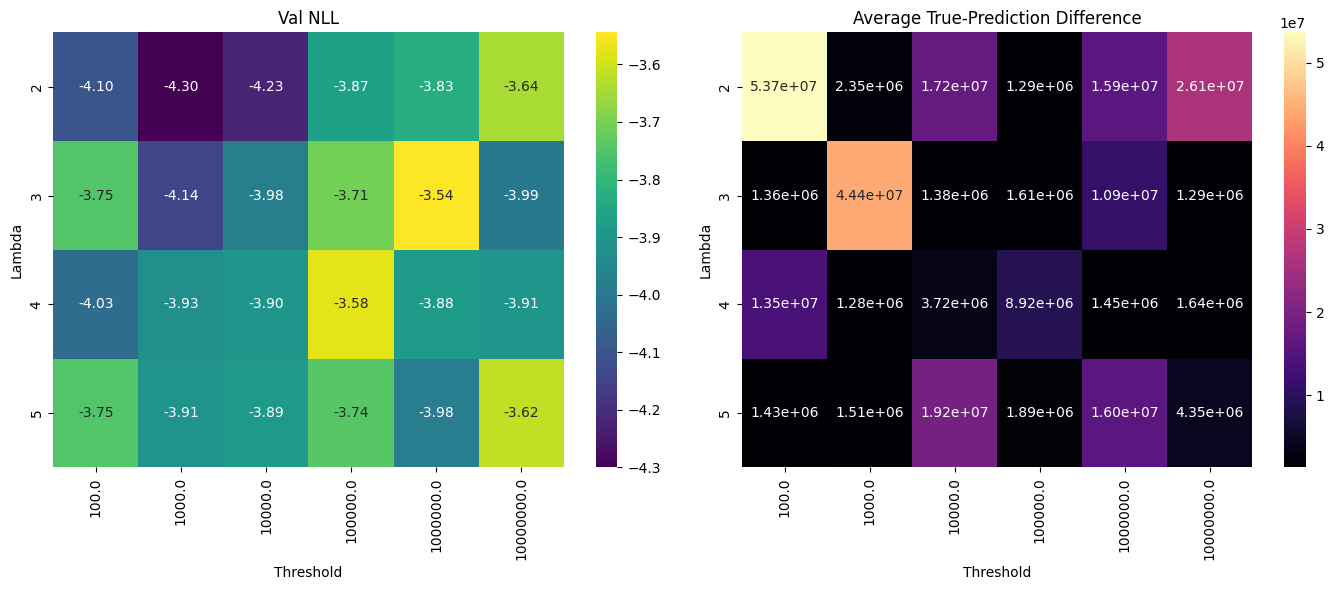

In [82]:
# Pivot tables for plotting
nll_pivot = res_df.pivot(index='Lambda', columns='Threshold', values='Val NLL')
diff_pivot = res_df.pivot(index='Lambda', columns='Threshold', values='Avg True-Pred Diff')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# NLL heatmap
sns.heatmap(nll_pivot, annot=True, fmt=".2f", cmap="viridis", ax=axes[0])
axes[0].set_title("Val NLL")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Lambda")

# Avg True-Prediction Difference heatmap, using scientific notation for better readability
sns.heatmap(diff_pivot, annot=True, fmt=".2e", cmap="magma", ax=axes[1])
axes[1].set_title("Average True-Prediction Difference")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Lambda")

plt.tight_layout()
plt.show()

Storm:  
thresh: log(1e3), lambda: 4 - Average absolute difference in DAMAGES: 891516.19  
thresh: log(1e4), lambda: 4 - Average absolute difference in DAMAGES: 877352.75  
thresh: log(1e5), lambda: 4 - Average absolute difference in DAMAGES: 863744.31  
thresh: log(1e6), lambda: 4 - Average absolute difference in DAMAGES: 750928.31  
thresh: log(1e7), lambda: 4 - Average absolute difference in DAMAGES: 1171222.12  
thresh: log(5e7), lambda: 4 - Average absolute difference in DAMAGES: 848773.62  
thresh: log(1e8), lambda: 4 - Average absolute difference in DAMAGES: 741730.62

thresh: log(1e6), lambda: 3 - Average absolute difference in DAMAGES: 875002.88  
thresh: log(1e6), lambda: 5 - Average absolute difference in DAMAGES: 933404.81  

thresh: .95 q, lambda: 5 - Average absolute difference in DAMAGES: 2220892.00  
thresh: .99 q, lambda: 5 - Average absolute difference in DAMAGES: 1608836.75